# End-to-end data pipeline: HinGE (English → Romanized Hinglish)

**DATA 298A · Team 2 · Topic 23 · Team Meeting 1**

This notebook runs the project's data pipeline stage by stage on the real HinGE release:

| # | Stage | Shows |
|---|---|---|
| 1 | **Extraction** | sources, collection steps, representative samples |
| 2 | **Cleaning** | missing values, transformations, formatting, validation |
| 3 | **Frozen splits** | disjoint train/dev/test, leakage check |
| 4 | **EDA** | statistics, plots, important findings |

Every cell calls the same code as the command-line pipeline (`pipeline/`), so the notebook and
`python pipeline/run_pipeline.py --input data/raw/HinGE.pkl` produce identical numbers. Nothing here is
hard-coded: re-running a cell recomputes it from the data.

In [1]:
import json, sys
from pathlib import Path

# Find the repository root, whether the notebook is opened from notebooks/ or from the root.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pipeline").is_dir())
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, Markdown, display
from pipeline import extract, clean, split, eda
from pipeline.common import INTERIM_DIR, PROCESSED_DIR, MANIFEST_DIR, REPORT_DIR

pd.set_option("display.max_colwidth", 120)
RAW = ROOT / "data" / "raw" / "HinGE.pkl"
HINGE_SHA256 = "e78c8f48af3eea0b141e767082189b7b619e9cbe50ad8f0b2a4863b82ebc5960"
assert RAW.exists(), f"Put HinGE.pkl at {RAW} first (see docs/datasheet.md)"
print("repo root:", ROOT)

repo root: /home/user/298a-team-2-topic-23/low-resource-and-code-switched-language-systems


---
## 1. Data extraction

### 1a. Sources
Licences were recorded in `docs/datasheet.md` **before** ingestion.

| Source | Role in the project | Licence | Used in 298A |
|---|---|---|---|
| **HinGE** (Srivastava & Singh, 2021) | English + Hindi + human Hinglish references; WAC/PAC machine outputs rated 1–10 | research use, cite the paper (inherits IIT Bombay CC-BY-NC) | **yes, extracted below** |
| MixMT 2022 Subtask-1 test set | Gahoi et al. baseline reproduction | research release | baseline |
| IIT Bombay En–Hi | source of HinGE's English/Hindi sentences | CC-BY-NC-4.0 | indirectly |
| Samanantar | parallel text for synthetic data (Model 4) | CC-BY-NC-4.0 (team decision) | 298B |
| Dakshina | Romanized ↔ Devanagari lexicons | CC BY-SA 4.0 | fertility slices |

**Why HinGE.pkl and not the released HinglishEval train/valid/test CSVs?** Those splits reuse HinGE's
sentences and **leak**: 75.8% of valid's and 78.1% of test's English sources also occur in train. We re-derive our own splits
in stage 3.

**Checking that claim live.** If the HinglishEval CSVs from the same Drive folder are copied to
`data/raw/HinglishEval/`, the next cell recomputes the overlap with the same normalisation the pipeline uses.

In [2]:
from pipeline.common import norm_key
he = ROOT / "data" / "raw" / "HinglishEval"
if (he / "train.csv").exists():
    keys = {n: {norm_key(e) for e in pd.read_csv(he / f"{n}.csv").English} for n in ("train", "valid", "test")}
    display(pd.DataFrame([{"released split": a, "unique sources": len(keys[a]),
                           "also in train": len(keys[a] & keys["train"]),
                           "% leaked": round(100 * len(keys[a] & keys["train"]) / len(keys[a]), 1)}
                          for a in ("valid", "test")]))
else:
    print("HinglishEval CSVs not found in data/raw/HinglishEval/ -- figure quoted from docs/datasheet.md (Yash's audit)")

,released split,unique sources,also in train,% leaked
0,valid,376,285,75.8
1,test,707,552,78.1


### 1b. Collection steps
1. Fingerprint the file (SHA-256) and refuse to load it if the hash is not the one we recorded
2. Load it and detect the columns by name
3. Profile it **as released**, before anything changes
4. Flatten it: every human reference, the WAC output and the PAC output each become one row
5. Write the flattened file (gitignored) and a manifest of counts and hashes (committed)
6. Print seeded random samples

In [3]:
raw_df = pd.read_pickle(RAW)   # the authors' release, exactly as distributed
print(raw_df.shape)
raw_df.head(3)

(1976, 9)


,English,Hindi,Human-generated Hinglish,WAC,WAC rating1,WAC rating2,PAC,PAC rating1,PAC rating2
0,It was presented to the Legislative Council in 1856 and was passed in 1860.,इसे 1856 में विधायी परिषद के समक्ष प्रस्तुत किया गया और1860 में पारित किया गया।,"[Ise 1856 mein legislative council ke samaksh prastut kiya gya and 1860 mein paarit kiya gya., Ise 1856 mein vidhai ...",ise 1856 men legislative council ke samaksh prastut kiya gaya aur1860 men parit kiya gaya.,9,6,ise 1856 men legislative council ke samaksh prastut kiya gaya aur1860 men parit kiya gaya.,9,8
1,"In the year 1985-86, the erstwhile Ministry of Welfare was bifurcated into the Department of Women and Child Develop...",वर्ष 1985-86 में पूर्ववर्ती कल्याण मंत्रालय को महिला एवं बाल विकास विभाग तथा कल्याण विभाग में विभक्त किया गया था।,"[In the year 1985-86, purvarti kalyan mantralay was bifurcated into mahila aevam baal vikaas vibhaag and kalyan vibh...",year 1985-86 men poorvavarti welfare ministry ko women evn erstwhile development department tatha welfare department...,10,4,year 1985-86 men poorvavarti kalyan mntralay ko mahila evn bal vikas vibhag tatha kalyan vibhag men vibhakt kiya gay...,10,10
2,"Connecting to the server, please wait...","सर्वर से कनेक्ट कर रहा है, कृपया इंतजार करें...","[Connecting to the server, kripya intezaar karein., Server se connect kar rhe hai, please wait., Server se connect k...","server se kanekt kar raha hai , wait intjar karen",5,5,"server se connecting kar raha hai, kripya wait karen",9,9


In [4]:
extract_record = extract.run(RAW, expected_sha256=HINGE_SHA256, n_samples=3, seed=42)


  STAGE 1: EXTRACTION
  source            : data/raw/HinGE.pkl
  sha256            : e78c8f48af3eea0b141e767082189b7b619e9cbe50ad8f0b2a4863b82ebc5960
  size              : 1,742,702 bytes


  columns found     : ['English', 'Hindi', 'Human-generated Hinglish', 'WAC', 'WAC rating1', 'WAC rating2', 'PAC', 'PAC rating1', 'PAC rating2']
  source rows       : 1,976
  unique English    : 1,973 (3 duplicated rows)
  human references  : 4,799 (mean 2.429 per source; distribution {'1': 23, '2': 1501, '3': 163, '4': 218, '5': 27, '6': 34, '7': 6, '8': 4})
  flattened rows    : 8,751 {'human': 4799, 'wac': 1976, 'pac': 1976}
  missing cells as released:
      English                          0
      Hindi                            0
      Human-generated Hinglish         0
      WAC                              0
      WAC rating1                      0
      WAC rating2                      0
      PAC                              0
      PAC rating1                      0
      PAC rating2                      0



  wrote 8,751 rows   -> data/interim/hinge_flat.tsv   (gitignored)
  wrote manifest     -> data/processed/manifests/extract_manifest.json   (commit this)

  representative samples (seed 42):

  [source 1309]
    English : Netaji received congratulations from Eamon De Velera , President of the Irish Free State .
    Hindi   : नेताजी को आइरिश फ्री स्टेट के अध्यक्ष इमौन डि बलेरा का बधाई संदेश भी मिला .
    Human 1 : From Eamon De Velera , President of the Irish Free State Netaji ko badhaai sandesh bhi mila.
    Human 2 : Netaji received congratulations Irish Free State ke adhyaksh Eamon De Velera ka.
    WAC     : netaji ko irish free state ke president eamon di velera ka congratulations sndesh bhi mila   (ratings 9, 9)
    PAC     : netaji ko aairish phri irish free state imaun di balera ka badhaee sndesh bhi mila   (ratings 2, 6)

  [source 228]
    English : very small change in time, we have a roughly constant
    Hindi   : बहुत छोटे परिवर्तन के समय में, हम एक मोटे तौर पर निरंतर है
 

### 1c. Representative samples (one row per reference after flattening)

In [5]:
flat = pd.read_csv(INTERIM_DIR / "hinge_flat.tsv", sep="\t", header=None, quoting=3,
                   names=extract_record["output"]["columns"], dtype=str, keep_default_na=False)
flat[flat.src_id == "228"][["english", "hinglish", "ref_source", "rating1", "rating2"]]

,english,hinglish,ref_source,rating1,rating2
1012,"very small change in time, we have a roughly constant","Bahut chhota change time me, hum roughly constant hain",human,,
1013,"very small change in time, we have a roughly constant","Bahut small change samay me, hum ek mote taur par constant hain",human,,
1014,"very small change in time, we have a roughly constant","Very small change samay me, we have a constant ek mote taur par",human,,
1015,"very small change in time, we have a roughly constant","Very small parivartan ke time me, hum ek mote taur par constant hain",human,,
1016,"very small change in time, we have a roughly constant","bahut small change ke time men , ham ek mote taur par constant hai",wac,8,7
1017,"very small change in time, we have a roughly constant","bahut chhote change in time men, ham ek roughly taur par nirntar hai",pac,10,8


In [6]:
prof = extract_record["profile"]
pd.DataFrame({
    "measure": ["source rows (English-Hindi pairs)", "unique English sources", "duplicated English rows",
                "human Hinglish references", "mean human refs per source", "flattened rows"],
    "value": [f"{prof['source_rows']:,}", f"{prof['unique_english_exact']:,}", f"{prof['duplicated_english_rows']:,}",
              f"{prof['human_refs_total']:,}", f"{prof['human_refs_mean_per_source']:.2f}", f"{prof['flat_rows']:,}"],
})

,measure,value
0,source rows (English-Hindi pairs),"1,976"
1,unique English sources,"1,973"
2,duplicated English rows,3
3,human Hinglish references,"4,799"
4,mean human refs per source,2.43
5,flattened rows,"8,751"


---
## 2. Data cleaning

An ordered list of rules; **every rule is counted**:
- **transform** (`~`): change a cell, keep the row (Unicode, invisible characters, quotes, PII, whitespace, ratings)
- **drop** (`-`): remove the row, with the reason recorded
- **flag** (`!`): keep the row, record the problem for the datasheet

**Deliberately not done:** Romanized spelling is never normalised and text is never lowercased.
Spelling variance (`nahi` / `nhi` / `nahin`) is what this project measures, so cleaning must not erase it.

In [7]:
clean_summary = clean.run()


  STAGE 2: CLEANING AND VALIDATION
  rows in: 8,751

  transforms


  ~ unicode_nfc                transform     14 rows   (remaining 8,751)


  ~ invisible_chars            transform      0 rows   (remaining 8,751)
  ~ punctuation_ascii          transform    662 rows   (remaining 8,751)


  ~ pii_mask                   transform     13 rows   (remaining 8,751)


  ~ whitespace                 transform   5354 rows   (remaining 8,751)
  ~ invalid_rating             transform      1 rows   (remaining 8,751)

  drops
  - missing_english            drop           0 rows   (remaining 8,751)
  - missing_hinglish           drop           0 rows   (remaining 8,751)


  - english_not_latin          drop           0 rows   (remaining 8,751)
  - hinglish_has_devanagari    drop          78 rows   (remaining 8,673)
  - hinglish_copies_english    drop           8 rows   (remaining 8,665)
  - length_ratio_outlier       drop          21 rows   (remaining 8,644)


  - duplicate_pair             drop         149 rows   (remaining 8,495)

  flags (kept, recorded)
  ! missing_hindi              flag           0 rows   (remaining 8,495)


  ! hindi_not_devanagari       flag          25 rows   (remaining 8,495)
  ! synthetic_missing_rating   flag           1 rows   (remaining 8,495)

  validation gate


    [PASS] schema: ref_source in human/wac/pac
    [PASS] no empty English
    [PASS] no empty Hinglish
    [PASS] no Devanagari in Hinglish
    [PASS] ratings integer in 1-10 or empty
    [PASS] human rows carry no ratings
    [PASS] no duplicate English+Hinglish pairs
    [PASS] no invisible characters in Latin columns
    [PASS] no leading/trailing/double whitespace
    [PASS] length ratio within bounds

  rows out: 8,495 {'human': 4751, 'wac': 1935, 'pac': 1809}  (256 dropped, 2.9%)
  note: 3 source(s) lost every human reference: src_id ['523', '1361', '1677']
  wrote -> data/interim/hinge_clean.tsv   (gitignored)
  wrote -> data/processed/manifests/clean_manifest.json   (commit this)
  wrote -> reports/data_pipeline/cleaning_report.json
  -- STAGE 2 finished in 3.0s


### 2a. Missing values: as extracted vs after cleaning

In [8]:
report = json.loads((REPORT_DIR / "cleaning_report.json").read_text())
miss = pd.DataFrame({"as extracted": {f"{c} / {s}": n for c, d in report["missing_before"].items() for s, n in d.items()},
                     "after cleaning": {f"{c} / {s}": n for c, d in report["missing_after"].items() for s, n in d.items()}})
miss
# Human references were never rated in HinGE, so their empty rating cells are structural, not missing data.

,as extracted,after cleaning
english / human,0,0
english / wac,0,0
english / pac,0,0
hinglish / human,0,0
hinglish / wac,0,0
hinglish / pac,0,0
hindi / human,0,0
hindi / wac,0,0
hindi / pac,0,0
ref_source / human,0,0


### 2b. Transformations, drops and flags: the cleaning ledger

In [9]:
ledger = pd.DataFrame([{k: e[k] for k in ("rule", "kind", "rows_affected", "rows_remaining", "description")}
                       for e in report["ledger"]])
ledger

,rule,kind,rows_affected,rows_remaining,description
0,unicode_nfc,transform,14,8751,Unicode NFC normalisation
1,invisible_chars,transform,0,8751,"zero-width, BOM, soft hyphen and control characters removed (ZWJ/ZWNJ kept inside Devanagari)"
2,punctuation_ascii,transform,662,8751,"curly quotes, dashes and ellipses to ASCII"
3,pii_mask,transform,13,8751,"URLs, e-mail addresses and phone numbers masked (<URL>, <EMAIL>, <PHONE>)"
4,whitespace,transform,5354,8751,whitespace collapsed and trimmed
5,invalid_rating,transform,1,8751,ratings outside 1-10 or non-numeric set to missing (not clipped)
6,missing_english,drop,0,8751,English source empty
7,missing_hinglish,drop,0,8751,Hinglish reference empty
8,english_not_latin,drop,0,8751,English column under 50% Latin letters (likely misaligned columns)
9,hinglish_has_devanagari,drop,78,8673,Hinglish reference contains Devanagari (target is Romanized)


### 2c. Formatting fixes: before and after examples

In [10]:
pd.DataFrame([{"rule": e["rule"], "before": x.get("before"), "after": x.get("after"), "dropped text": x.get("text")}
              for e in report["ledger"] if e["rows_affected"] and e["kind"] != "flag"
              for x in e["examples"][:1]])

,rule,before,after,dropped text
0,unicode_nfc,[hindi] और निश्चय ही तुम्हारे लिए चौपायों में भी एक शिक्षा है। उनके पेटों में जो कुछ है उसमें से हम तुम्हें पिलाते ह...,[hindi] और निश्चय ही तुम्हारे लिए चौपायों में भी एक शिक्षा है। उनके पेटों में जो कुछ है उसमें से हम तुम्हें पिलाते ह...,NaN
1,punctuation_ascii,[hinglish] Is it possible to know one’s saccha swaroop?,[hinglish] Is it possible to know one's saccha swaroop?,NaN
2,pii_mask,"[english] Sofree, Giannie, Gandhi and India: A century in the center (1995) ISBN 1 - 900624 - 12 - 5","[english] Sofree, Giannie, Gandhi and India: A century in the center (1995) ISBN <PHONE>",NaN
3,whitespace,[hinglish] Ise 1856 me legislative council ke samaksh present kiya gaya aur 1860 me pass kiya.,[hinglish] Ise 1856 me legislative council ke samaksh present kiya gaya aur 1860 me pass kiya.,NaN
4,invalid_rating,rating2=0,missing,NaN
5,hinglish_has_devanagari,NaN,NaN,"juvenile justice board ne prakat lower se appellant ko , १३ ०८ २००३ par uski age २० years manakar , jo medical board..."
6,hinglish_copies_english,NaN,NaN,image format default rgb
7,length_ratio_outlier,NaN,NaN,CMMS:
8,duplicate_pair,NaN,NaN,ise 1856 men legislative council ke samaksh prastut kiya gaya aur1860 men parit kiya gaya.


### 2d. Validation gate: nothing is written unless every check passes

In [11]:
pd.DataFrame({"check": list(clean_summary["validation"]),
              "result": ["PASS" if v else "FAIL" for v in clean_summary["validation"].values()]})

,check,result
0,schema: ref_source in human/wac/pac,PASS
1,no empty English,PASS
2,no empty Hinglish,PASS
3,no Devanagari in Hinglish,PASS
4,ratings integer in 1-10 or empty,PASS
5,human rows carry no ratings,PASS
6,no duplicate English+Hinglish pairs,PASS
7,no invisible characters in Latin columns,PASS
8,no leading/trailing/double whitespace,PASS
9,length ratio within bounds,PASS


---
## 3. Frozen splits and leakage check

`scripts/make_splits.py` (Yash, Sarvesh) groups exact and MinHash near-duplicate sentences into clusters, then assigns
whole clusters to train/dev/test (80/10/10, seed 42). We then check leakage independently. Dev/test references are
**human-written only**: WAC/PAC machine outputs are never used as references.

In [12]:
split_report = split.run()


  STAGE 3: FROZEN SPLITS AND LEAKAGE CHECK
  $ python scripts/make_splits.py --input data/interim/hinge_clean.tsv --seed 42



    | rows                    : 8495
    | exact-normalised keys   : 1973
    |   of which multi-row    : 1973
    | MinHash clusters        : 1972
    |   exact keys merged by MinHash beyond normalisation: 1
    | 
    | verifying disjointness
    |   OK: no key appears in more than one split
    | 
    | verifying the splits are not degenerate
    |   largest cluster: 10 rows (0.1% of the corpus)
    |   train    6799 rows   80.0% (requested 80%)
    |   dev       836 rows    9.8% (requested 10%)
    |   test      860 rows   10.1% (requested 10%)
    |   OK: every split is populated and close to its requested share
    | 
    |   train    6799 rows  ef578e442232bc96...  -> /home/user/298a-team-2-topic-23/low-resource-and-code-switched-language-systems/data/processed/train.tsv
    |   dev       836 rows  204b51b94310b700...  -> /home/user/298a-team-2-topic-23/low-resource-and-code-switched-language-systems/data/processed/dev.tsv
    |   test      860 rows  f9c4926590e83ab5...  -> /hom


  model-ready exports
    train.human.tsv                          3812
    dev_refs_dropped_seen_in_train           0
    dev_sources                              197
    dev_sources_exported                     196
    dev_sources_excluded_no_human_ref        1
    dev_sources_excluded_no_hindi            0
    dev_refs_per_source_mean                 2.357
    test_refs_dropped_seen_in_train          2
    test_sources                             198
    test_sources_exported                    197
    test_sources_excluded_no_human_ref       1
    test_sources_excluded_no_hindi           0
    test_refs_per_source_mean                2.411
    slices/en.txt                            1578
    slices/hi_deva.txt                       1578
    slices/hinglish.txt                      3812

  wrote -> reports/data_pipeline/split_report.json
  -- STAGE 3 finished in 5.5s


In [13]:
pd.DataFrame({"rows": split_report["rows"], "unique English sources": split_report["unique_english"]})

,rows,unique English sources
train,6799,1578
dev,836,197
test,860,198


In [14]:
pd.Series(split_report["leakage"], name="shared items").to_frame()

,shared items
english train&dev,0
human hinglish train&dev,0
english train&test,0
human hinglish train&test,2
english dev&test,0
human hinglish dev&test,0
gold_set_items_checked,0
gold english & train,0
gold english & dev,0


The 2 shared *human Hinglish* references are **misaligned references inside HinGE**: a test sentence carries
references that actually translate a different sentence that sits in train. Their English sources differ, so
cluster-based splitting cannot see it; the export step drops them from the test files (`test_refs_dropped_seen_in_train`).

---
## 4. Exploratory data analysis

In [15]:
summary = eda.run()
FIG = REPORT_DIR / "figures"


  STAGE 4: EXPLORATORY DATA ANALYSIS


  language-tagged human refs -> data/interim/hinge_tagged.conll  (input for 298-22 --cmi-only)



  key findings
   1. Cleaning kept 8,495 of 8,751 flattened rows (97.1%); the largest drop rule was `duplicate_pair` (149 rows). All 10 validation checks passed on the output.

   2. With the sentence held fixed, annotators who used the same lexicon word spelled it differently in 9.9% of 708 cases; 28 of the 68 lexicon words found in the corpus occur in two or more spellings. This is weak evidence for the orthographic-variance hypothesis.

   3. Human references are genuinely code-mixed: mean CMI 34.0, 98% of sentences contain both languages, switch-point fraction 0.191. Tags are heuristic and CMI is a lower bound. This SPF is the target for SPF-matched synthetic sampling in Model 4.

   4. Machine-generated references: mean rating WAC 7.36, PAC 7.07 on 1-10. Rater agreement (Krippendorff's alpha, ordinal) is 0.18 for WAC (unreliable) and 0.07 for PAC (unreliable). WAC/PAC are never used as dev/test references; whether and at what rating they enter training is a logged modelling decis

### 4a. What cleaning changed
Rows per reference source before and after cleaning, and rows touched by each rule.

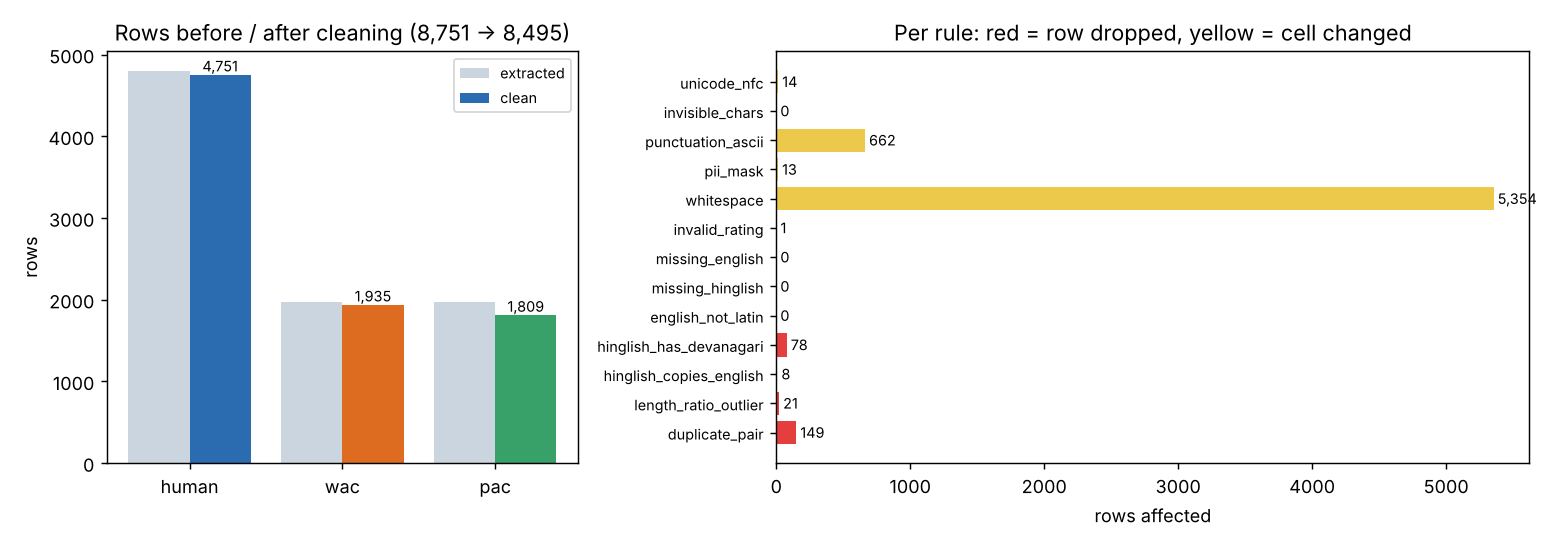

In [16]:
display(Image(filename=str(FIG / "01_cleaning_waterfall.png")))

### 4b. Corpus shape
How many human references each English sentence has, and how rows divide between human, WAC and PAC.

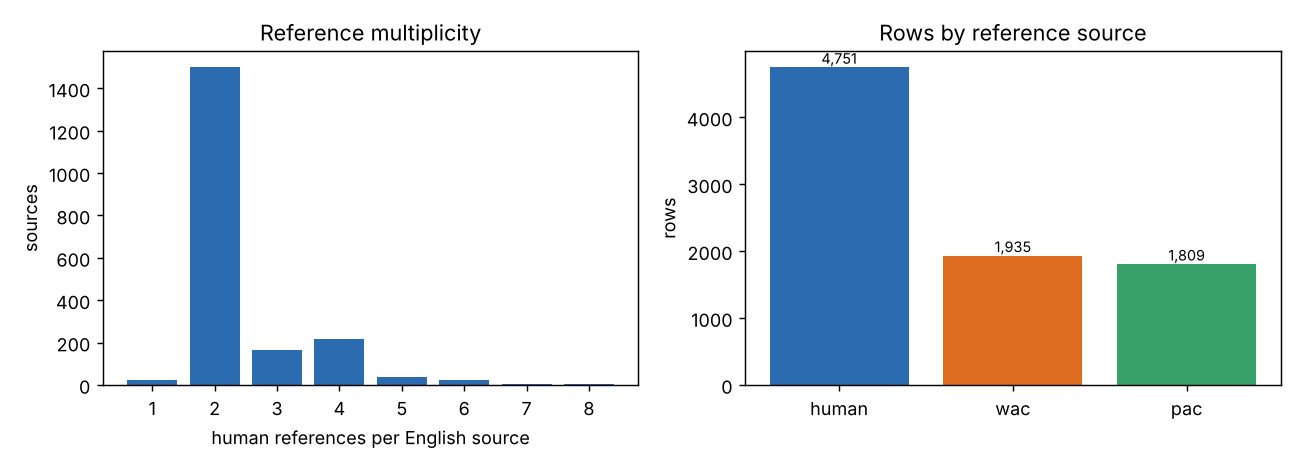

In [17]:
display(Image(filename=str(FIG / "03_reference_multiplicity.png")))

### 4c. Sentence length and alignment
Word counts per column, and the Hinglish/English length ratio. The dashed lines are the cleaning bounds.

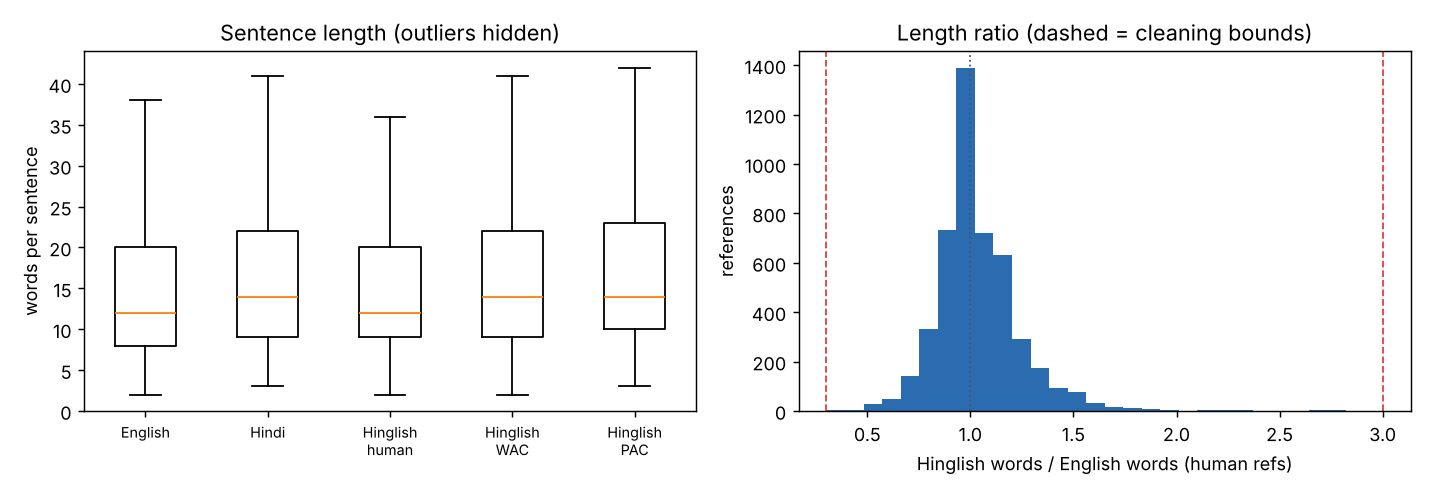

In [18]:
display(Image(filename=str(FIG / "04_lengths.png")))

### 4d. WAC/PAC quality ratings and rater agreement
Two raters scored every machine output from 1 to 10. If the two raters agreed, the dots would sit on the diagonal.

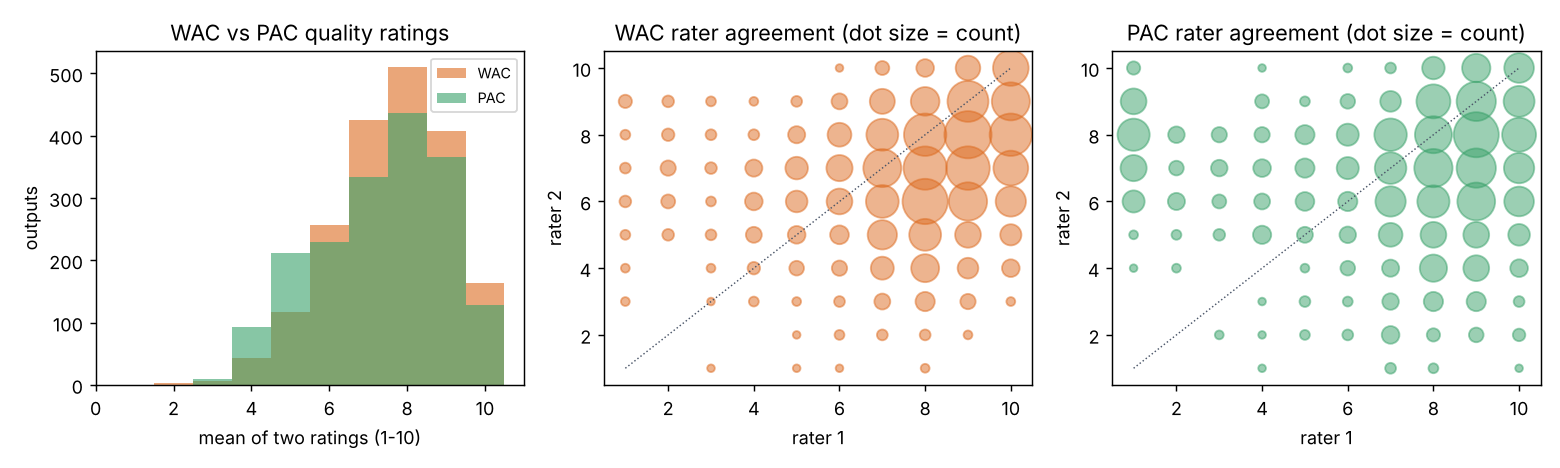

In [19]:
display(Image(filename=str(FIG / "05_ratings.png")))

### 4e. How code-mixed is the text?
Code-Mixing Index per sentence (heuristic language tags; the English share is a lower bound).

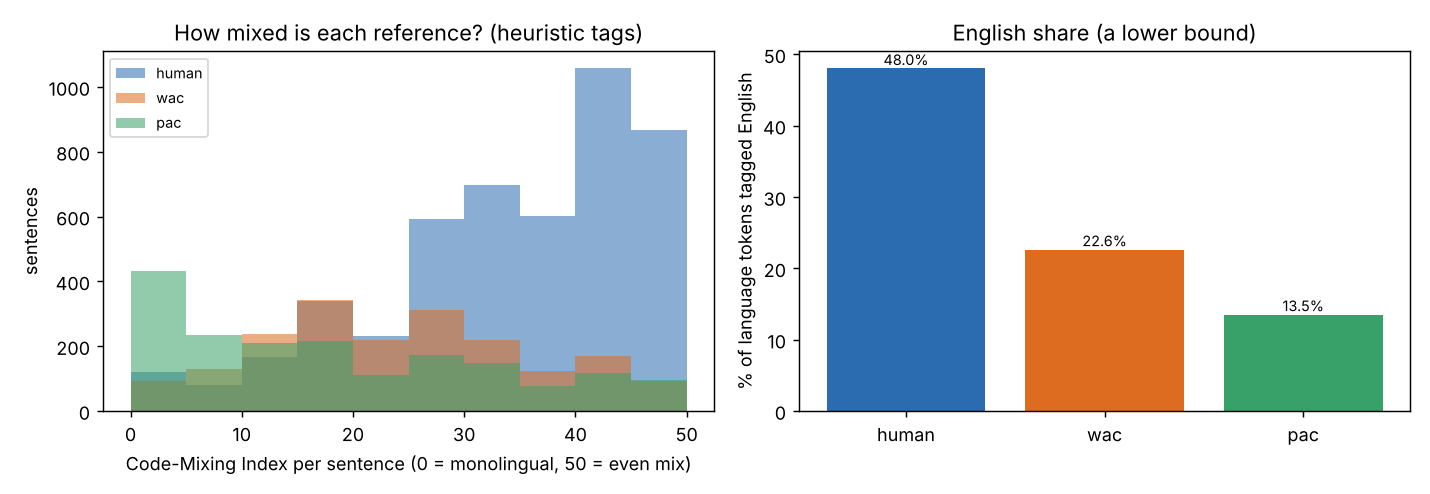

In [20]:
display(Image(filename=str(FIG / "06_code_mixing.png")))

### 4f. Is spelling unstable? (the project's hypothesis)
Which spellings annotators actually used for the most frequent lexicon words.

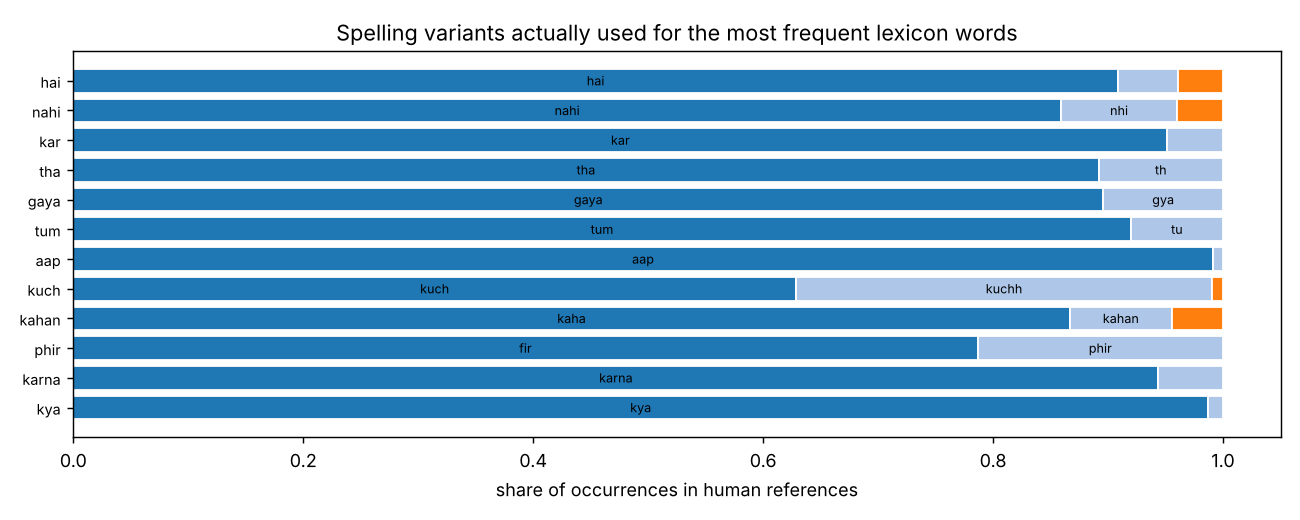

In [21]:
display(Image(filename=str(FIG / "07_spelling_variants.png")))

### 4g. Most frequent words
Blue = Hindi, orange = English.

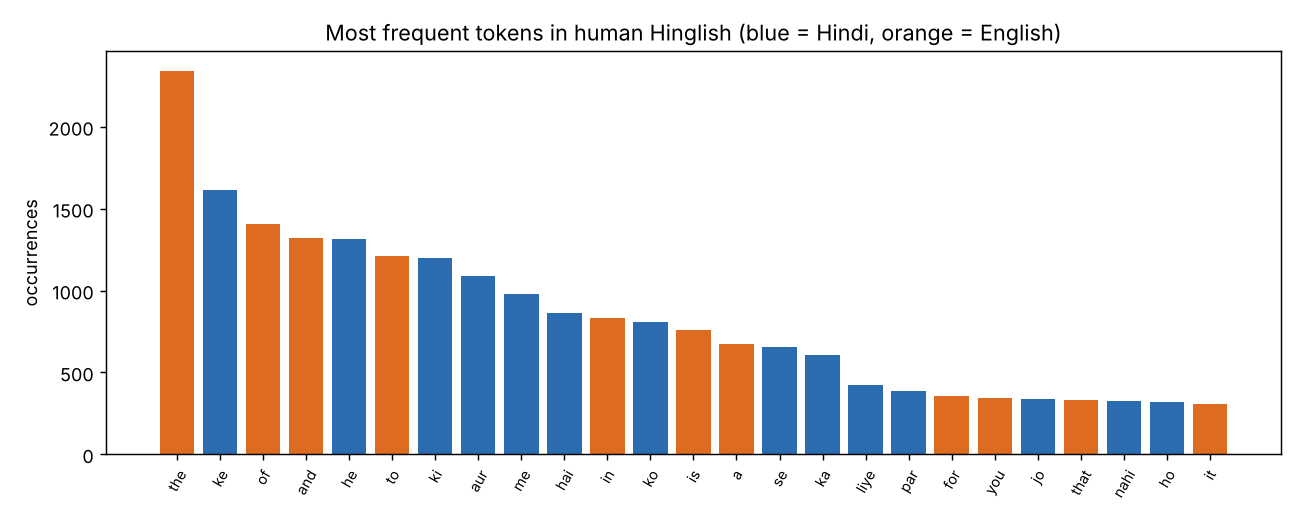

In [22]:
display(Image(filename=str(FIG / "08_top_tokens.png")))

### 4h. Are the splits comparable?
Size, sentence length and code-mixing per split.

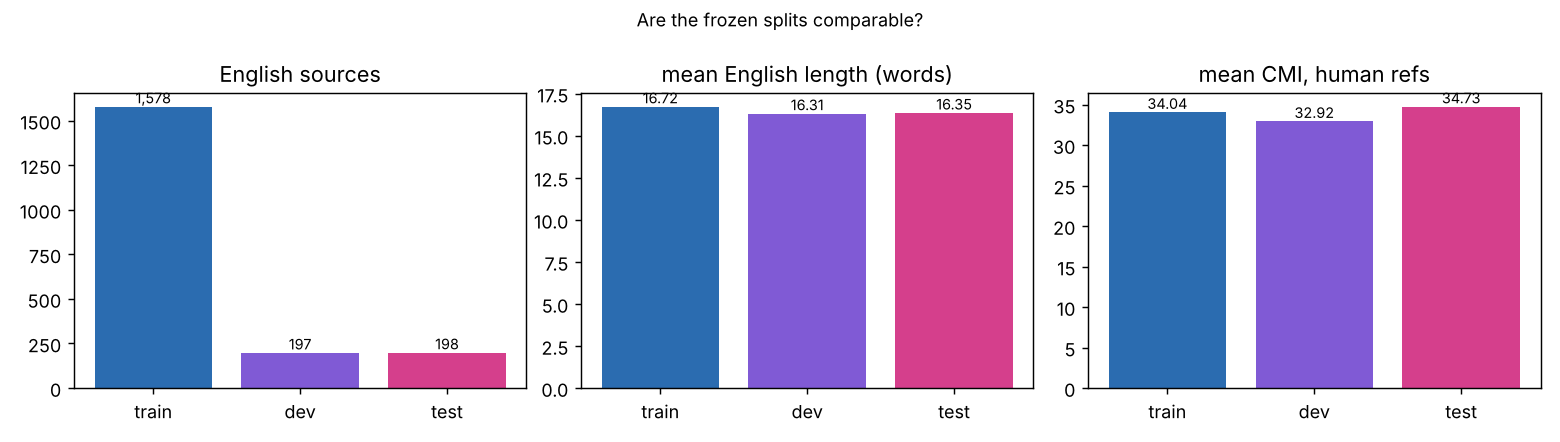

In [23]:
display(Image(filename=str(FIG / "09_split_comparison.png")))

### 4i. Key statistics

In [24]:
pd.DataFrame(summary["lengths"]).T[["n", "mean", "median", "std", "min", "max"]]

,n,mean,median,std,min,max
english,1973.0000,16.6410,12.0000,13.4700,2.0000,150.0000
hindi,1973.0000,18.6780,14.0000,15.2040,3.0000,148.0000
hinglish_human,4751.0000,16.6630,12.0000,13.0620,2.0000,152.0000
hinglish_wac,1935.0000,18.4770,14.0000,15.0750,2.0000,144.0000
hinglish_pac,1809.0000,19.1210,14.0000,15.3660,3.0000,144.0000
ratio_hinglish_over_english,4751.0000,1.0430,1.0000,0.2080,0.3030,3.0000
share_ratio_0.5_to_2.0,0.9947,0.9947,0.9947,0.9947,0.9947,0.9947


In [25]:
pd.DataFrame(summary["ratings"])

,wac,pac
n_pairs,1935.000,1808.000
mean_rating,7.360,7.072
std_rating,1.467,1.638
exact_agreement,0.187,0.147
within_one,0.469,0.415
spearman,0.288,0.097
krippendorff_alpha_ordinal,0.180,0.070
share_mean_below_5,0.052,0.114


In [26]:
pd.DataFrame(summary["code_mixing"])

,human,wac,pac
n_utterances,4751.000000,1935.000000,1809.000000
n_tokens,90548.000000,38274.000000,36951.000000
n_language_tokens,74444.000000,34010.000000,33812.000000
cmi_mean_all,33.998476,24.120440,18.034848
cmi_mean_mixed_only,34.841837,25.120050,22.751074
frac_utterances_mixed,0.975795,0.960207,0.792703
switch_point_fraction,0.191038,0.345378,0.128738
n_switch_points,13314.000000,11078.000000,4120.000000
m_index,0.996852,0.538463,0.305039
burstiness,0.090968,0.060026,0.244913


In [27]:
pd.DataFrame(summary["spelling_variants"]["top_disagreements"])

,group,forms,sentences
0,hai,h / hai,21
1,hai,hai / hain,11
2,nahi,nahi / nai,6
3,kuch,kuch / kuchh,6
4,kar,kar / kr,5
5,gaya,gaya / gya,3
6,tha,th / tha,3
7,nahi,nahi / nhi,2
8,pata,pata / pta,2
9,tum,tu / tum,2


### 4j. Important findings (generated from the numbers above)

In [28]:
display(Markdown("\n".join(f"{i}. {t}" for i, t in enumerate(summary["findings"], 1))))

1. Cleaning kept 8,495 of 8,751 flattened rows (97.1%); the largest drop rule was `duplicate_pair` (149 rows). All 10 validation checks passed on the output.
2. With the sentence held fixed, annotators who used the same lexicon word spelled it differently in 9.9% of 708 cases; 28 of the 68 lexicon words found in the corpus occur in two or more spellings. This is weak evidence for the orthographic-variance hypothesis.
3. Human references are genuinely code-mixed: mean CMI 34.0, 98% of sentences contain both languages, switch-point fraction 0.191. Tags are heuristic and CMI is a lower bound. This SPF is the target for SPF-matched synthetic sampling in Model 4.
4. Machine-generated references: mean rating WAC 7.36, PAC 7.07 on 1-10. Rater agreement (Krippendorff's alpha, ordinal) is 0.18 for WAC (unreliable) and 0.07 for PAC (unreliable). WAC/PAC are never used as dev/test references; whether and at what rating they enter training is a logged modelling decision.
5. Human Hinglish has a median of 1.00x the English word count; 99.5% of references fall between 0.5x and 2.0x. English sources average 16.6 words.
6. 16.4% of test-set Hinglish tokens never occur in train, and 49% of train word types occur only once.
7. Frozen splits: 0 English sources shared across train/dev/test after exact and MinHash near-duplicate grouping, re-checked independently of make_splits.py.

### What these findings mean for the project
- **HinGE is good supervision:** its references really are code-mixed, and the pairs are well aligned.
- **HinGE is formal text** (IIT Bombay: software strings, legal and government prose), not casual chat, and spelling
  disagreement within a sentence is modest. We therefore add **PHINC** (13.7k social-media Hinglish pairs) to test the
  spelling-variance hypothesis on casual text.
- **WAC/PAC ratings are unreliable** (very low rater agreement), so they are never used to weight or filter training data.

---
## 5. Reproducibility
The manifests are committed: anyone with the same HinGE.pkl gets byte-identical splits.

In [29]:
m = json.loads((MANIFEST_DIR / "hinge_split_manifest.json").read_text())
pd.DataFrame({k: {"rows": v["rows"], "sha256": v["sha256"][:16] + "..."} for k, v in m["splits"].items()}).T

,rows,sha256
train,6799,ef578e442232bc96...
dev,836,204b51b94310b700...
test,860,f9c4926590e83ab5...


In [30]:
import subprocess
print(subprocess.run([sys.executable, "-m", "pytest", "-q", "--color=no", str(ROOT / "tests")],
                     cwd=ROOT, capture_output=True, text=True).stdout[-300:])

..........................                                               [100%]
26 passed in 9.71s

